# Notebook 0 - Input data preparation

<hr>
This key module helps the user prepare all the input data (currently for module 1)

Prepared by Dario Spiller, Geospatial Unit at the Land and Water Division, FAO HQ
<hr>


In [1]:
'''import supporting libraries'''
# import pyaez
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
try:
    from osgeo import gdal
except:
    import gdal
import sys
import geopandas as gpd
import cavapy
import xarray as xr
import rasterio
from rasterio.transform import from_bounds
from rasterio.crs import CRS
from rasterio.plot import show
from rasterio.mask import mask
from rasterio.features import rasterize
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling

os.environ['PROJ_LIB'] = '/opt/conda/envs/pyAEZ/share/proj'
gdal.UseExceptions()

In [2]:
# Set the working directory
work_dir = r'/workspaces/Python-AEZ-FAO'  # Please change this to your working directory
os.chdir(work_dir)
sys.path.append(work_dir)
os.getcwd()


'/workspaces/Python-AEZ-FAO'

In [3]:
from module0 import pre_proc_utilities

In [4]:

import importlib
import module0.pre_proc_utilities
importlib.reload(module0.pre_proc_utilities)


<module 'module0.pre_proc_utilities' from '/workspaces/Python-AEZ-FAO/module0/pre_proc_utilities.py'>

# Input data from the user

In [5]:
country_name = 'Togo'
years_list = [1980]
rcp = "rcp26"
gcm = "MOHC" # [MOHC, NCC, MPI]
rcm = 'REMO' # [ICTP, REMO] 
historical = True


# Loading the reference UN shapefile (level 1)

In [6]:
country_name = country_name.lower()
AOI = pre_proc_utilities.get_UN_country(country_name, thr=3, return_gdf=False)

The country "Togo" was selected from the UN  database.


# Loading climate data 

In [7]:
years_up_to = np.max([np.max(years_list)+1, 2007])   
years_obs = range(1980,np.min([np.max(years_list)+1,2019]))
country_name_capitalized = country_name.capitalize()

if np.max(years_list) < 2007:
    # For historical data bias correction is not needed
    bias_correction = False
else:
    bias_correction = True
    
CAVA_climate_data = cavapy.get_climate_data(country=country_name_capitalized, 
                                             cordex_domain="AFR-22", 
                                             buffer=1,
                                             rcp=rcp, 
                                             gcm=gcm, 
                                             rcm=rcm, 
                                             num_processes=10,
                                             years_up_to=years_up_to, 
                                             obs=True, 
                                             bias_correction=bias_correction, 
                                             historical=historical, 
                                             years_obs=years_obs)


print('CAVA data fully retrieved!')
ds = CAVA_climate_data

2025-09-22 06:25:06,684 | climate.URL-validation-observations | 812:125925688129024 [INFO]: https://hub.ipcc.ifca.es/thredds/dodsC/fao/observations/ERA5/0.25/ERA5_025.ncml
2025-09-22 06:25:07,586 | climate.hurs-observations | 1999:125924595701440 [INFO]: Establishing connection to ERA5 data for hurs(hurs)
2025-09-22 06:25:07,587 | climate.sfcWind-observations | 2000:125924595701440 [INFO]: Establishing connection to ERA5 data for sfcWind(sfcwind)
2025-09-22 06:25:07,597 | climate.pr-observations | 1996:125924595701440 [INFO]: Establishing connection to ERA5 data for pr(tp)
2025-09-22 06:25:07,600 | climate.tasmin-observations | 1998:125924595701440 [INFO]: Establishing connection to ERA5 data for tasmin(t2mn)
2025-09-22 06:25:07,595 | climate.tasmax-observations | 1997:125924595701440 [INFO]: Establishing connection to ERA5 data for tasmax(t2mx)
2025-09-22 06:25:07,593 | climate.rsds-observations | 2001:125924595701440 [INFO]: Establishing connection to ERA5 data for rsds(ssrd)
2025-09

CAVA data fully retrieved!


## Exporting CAVA data

In [8]:
pre_proc_utilities.export_cava_data(ds, years_list, output_folder='./data_input/CAVA_data/')

Exporting pr...
Exporting tasmax...
Exporting tasmin...
Exporting hurs...


/opt/conda/envs/pyaez/lib/python3.12/site-packages/numpy/lib/format.py:383: UserWarning: metadata on a dtype is not saved to an npy/npz. Use another format (such as pickle) to store it.
  d['descr'] = dtype_to_descr(array.dtype)


Exporting sfcWind...
Exporting rsds...


## Defining the rasterized country AOI

In [22]:
pre_proc_utilities.rasterize_country_from_geodataframe(ds, AOI, country_name, output_dir='./data_input/')

Rasterized country saved to ./data_input/togo_rasterized.tif


## Defining the DEM for the AOI at the original resolution

In [23]:
DEM_raster_path = r'./data_input/DEM/altmed30s.tif'
pre_proc_utilities.clip_raster_with_geometry(DEM_raster_path, AOI, country_name, output_dir='./data_input/')

Clipped raster saved to ./data_input/togo_elevation_clipped.tif


'./data_input/togo_elevation_clipped.tif'

## Defining the DEM for the AOI at the scaled resolution

Unique values: [6.0 22.0 35.0 60.0 72.0 97.0 99.0 100.0 108.0 112.0]


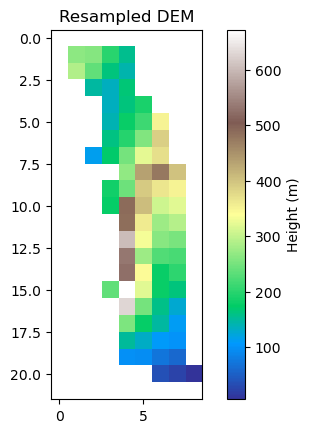

In [29]:
elv = process_raster(INPUT_raster_path = './data_input/DEM/altmed30s.tif', 
                  ref_raster_path = f'./data_input/{country_name}_rasterized.tif',
                  output_clipped_path = f'./data_input/{country_name}_elevation_resampled_clipped.tif',
                  ref_geom = AOI.geometry, plot=True, title = 'Resampled DEM', colorbar_label = 'Height (m)', cmap='terrain')


## Defining the LULC layer for the AOI at the scaled resolution

Unique values: [3.0 4.0 5.0 --]


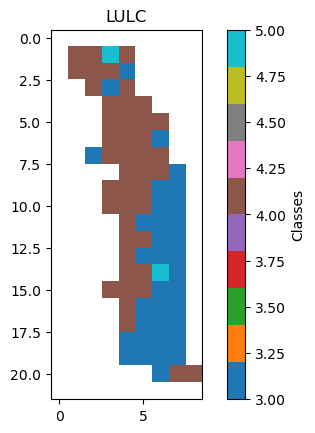

In [30]:
lulc = process_raster(INPUT_raster_path = './data_input/LULC/soil_regime_CRUTS32_Hist_8110.tif', 
                  ref_raster_path = f'./data_input/{country_name}_rasterized.tif',
                  output_clipped_path = f'./data_input/{country_name}_lulc_resampled_clipped.tif',
                  ref_geom = AOI.geometry, plot=True, title = 'LULC', colorbar_label = 'Classes', cmap='tab10')